# HF TDOA Analysis - Figures 13 & 14

This notebook uses the `hf_tdoa_lib` library to analyze HF TDOA measurements and generate Figures 13 and 14.

In [1]:
import os
import datetime
import importlib
import hf_tdoa_lib as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps

In [ ]:
base_dir   = 'data'
data_set   = 'TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('templates', 'N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir, data_set)
wavlist    = tdoa.obtain_wav_list(data_dir)

In [3]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = tdoa.find_chirps(wavlist, template, sweep_rate=sweep_rate, plot_correlation=False)

## Find TDOAs

In [4]:
debug_TDOAs = False

# Access the path_info object to calculate TDOA models automatically
path_info = chirps.attrs['path_info']

tdoa_dct = {}

### 1F2-2F2 (Default mode)
tdoa_dct['1F2-2F2']  = dct = {}
dct['filter_limts']  = [10,50]          # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,11,20] # (start_offset, end_offset, min_freq, max_freq)
dct['mode_string']   = '2F2-1F2'        # Propagation mode for TDOA calculation
dct['model_coeffs']  = path_info.calculate_TDOA_model(dct['mode_string'])
dct['linestyle']     = '--'
dct['linewidth']     = 3
dct['color']         = 'tab:green'
dct['marker']        = 'o'

### 1F2-1E
tdoa_dct['1F2-1E']   = dct = {}
dct['filter_limts']  = [2.5,30]        # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,5,12] # (start_offset, end_offset, min_freq, max_freq)
dct['mode_string']   = '1F2-1E'        # Propagation mode for TDOA calculation
dct['model_coeffs']  = path_info.calculate_TDOA_model(dct['mode_string'])
dct['linestyle']     = '-.'
dct['linewidth']     = 1.5
dct['color']         = 'tab:blue'
dct['marker']        = '*'

### 2F2-1E
tdoa_dct['2F2-1E'] = dct = {}
dct['filter_limts']  = [20,30]          # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,22,30] # (start_offset, end_offset, min_freq, max_freq)
dct['mode_string']   = '2F2-1E'        # Propagation mode for TDOA calculation
dct['model_coeffs']  = path_info.calculate_TDOA_model(dct['mode_string'])
dct['linestyle']     = ':'
dct['linewidth']     = 2.5
dct['color']         = 'tab:orange'
dct['marker']        = '^'

# Print calculated model coefficients for verification
print("Calculated TDOA Model Coefficients:")
print("=" * 60)
for set_name, params in tdoa_dct.items():
    slope, intercept = params['model_coeffs']
    mode_str = params['mode_string']
    print(f"{set_name:12s} ({mode_str:8s}): slope={slope:6.1f}, intercept={intercept:6.1f}")
print("=" * 60)
print()

for set_name, params in tdoa_dct.items():
    filter_limts  = params['filter_limts']
    search_limits = params['search_limits']
    chirps        = tdoa.find_TDOAs(chirps, search_limits, filter_limts, set_name=set_name,
                                   plot_fft=debug_TDOAs, only_one=debug_TDOAs)

/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/fig_11_12/hf_tdoa_lib.py:639: RuntimeWarning: Mean of empty slice
  mean_beats.append(np.nanmean(beat_arr))


## Figure 13 - TDOA Measurements

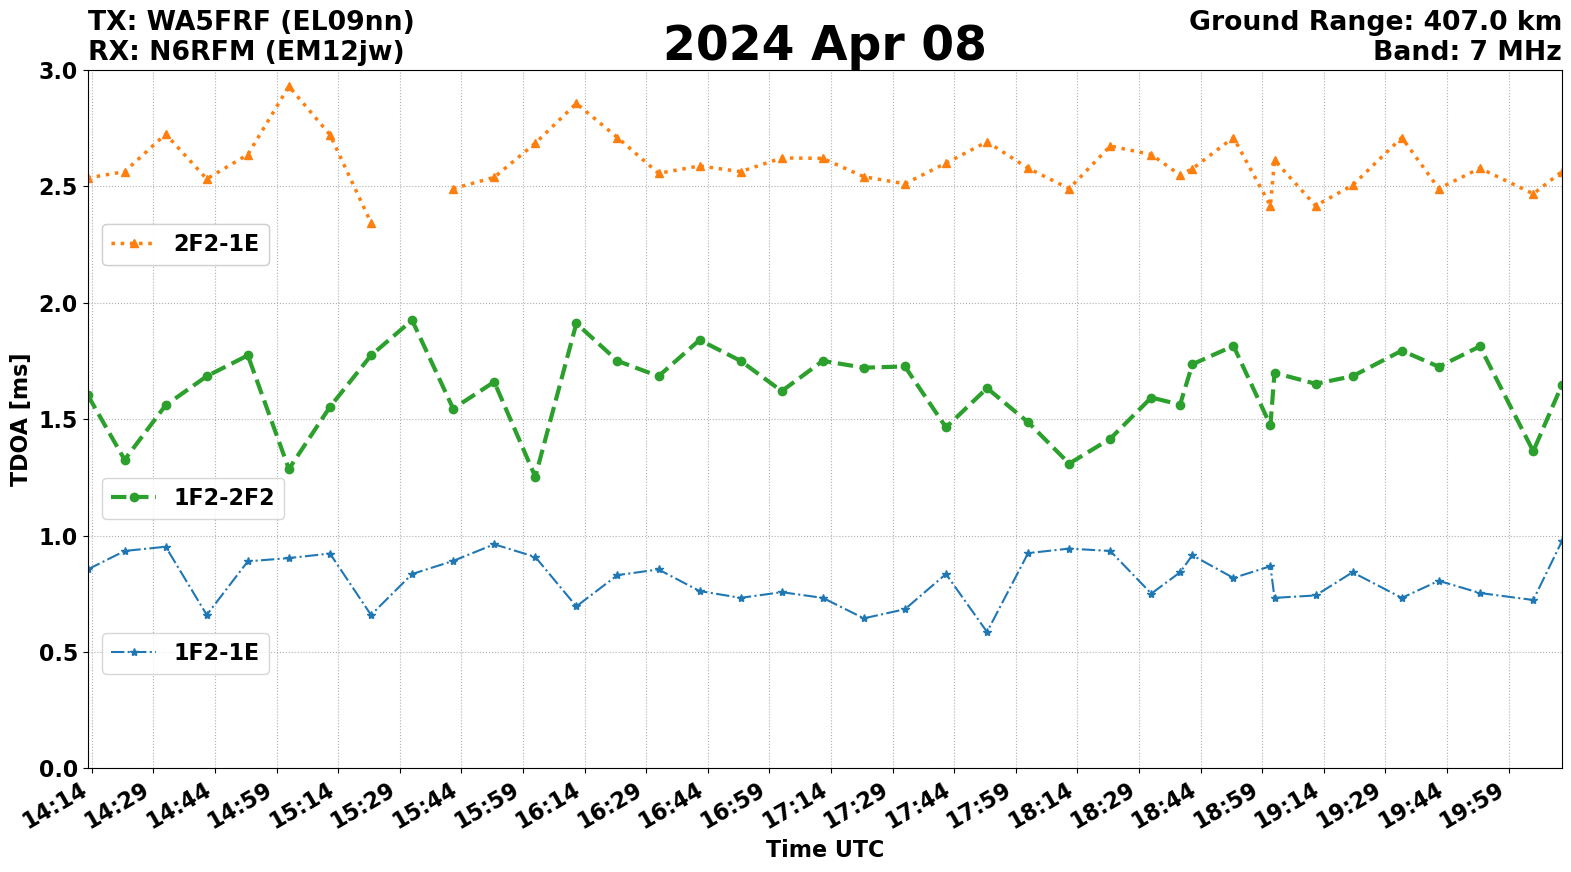

In [5]:
tdoa.plot_TDOAs(chirps, tdoa_dct)

## Figure 14 - Layer Heights Comparison with Ionosonde

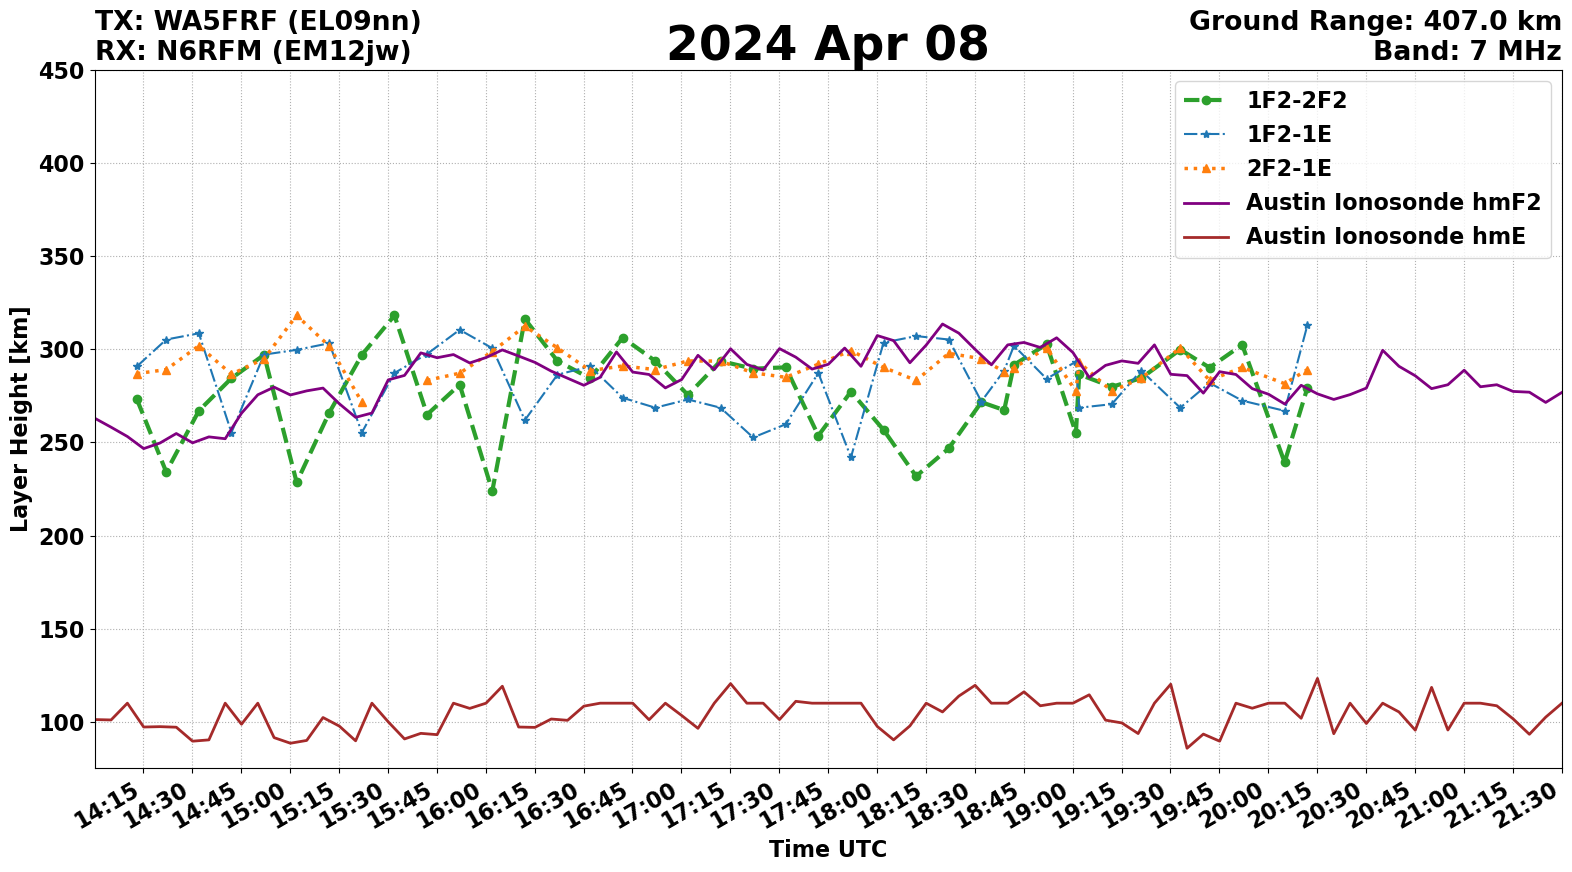

In [6]:
tdoa.plot_hmf2(chirps, tdoa_dct, ionosonde_dct=True)

## Path Information

The `path_info` object provides convenient access to TX/RX coordinates and other path-related calculations.

In [7]:
# Access the path_info object stored when chirps were created
path_info = chirps.attrs['path_info']

# Display path information
print(f"Path Information:")
print(f"  {path_info}")
print()

# Get TX and RX coordinates from gridsquares
tx_lat, tx_lon = path_info.get_tx_latlon()
rx_lat, rx_lon = path_info.get_rx_latlon()
print(f"TX Location: {tx_lat:.3f}°N, {tx_lon:.3f}°E ({path_info.tx_grid})")
print(f"RX Location: {rx_lat:.3f}°N, {rx_lon:.3f}°E ({path_info.rx_grid})")
print()

# Calculate the great circle midpoint between TX and RX
mid_lat, mid_lon = path_info.get_midpoint()
print(f"Path Midpoint: {mid_lat:.3f}°N, {mid_lon:.3f}°E")
print()

# Calculate the azimuth from TX to RX
azimuth = path_info.get_path_azimuth()
print(f"Path Azimuth (TX→RX): {azimuth:.1f}°")
print()

Path Information:
  PathInfo(TX: WA5FRF (EL09nn), RX: N6RFM (EM12jw), Range: 407.0 km, Band: 7 MHz)

TX Location: 29.563°N, -98.875°E (EL09nn)
RX Location: 32.938°N, -97.208°E (EM12jw)

Path Midpoint: 31.253°N, -98.057°E

Path Azimuth (TX→RX): 22.5°



## Figure 14 (Enhanced) - Layer Heights with Solar Elevation and Eclipse Obscuration

This version of Figure 14 includes overlays for Solar Elevation Angle and Eclipse Obscuration.
The solar coordinates are automatically calculated from the TX/RX path midpoint.

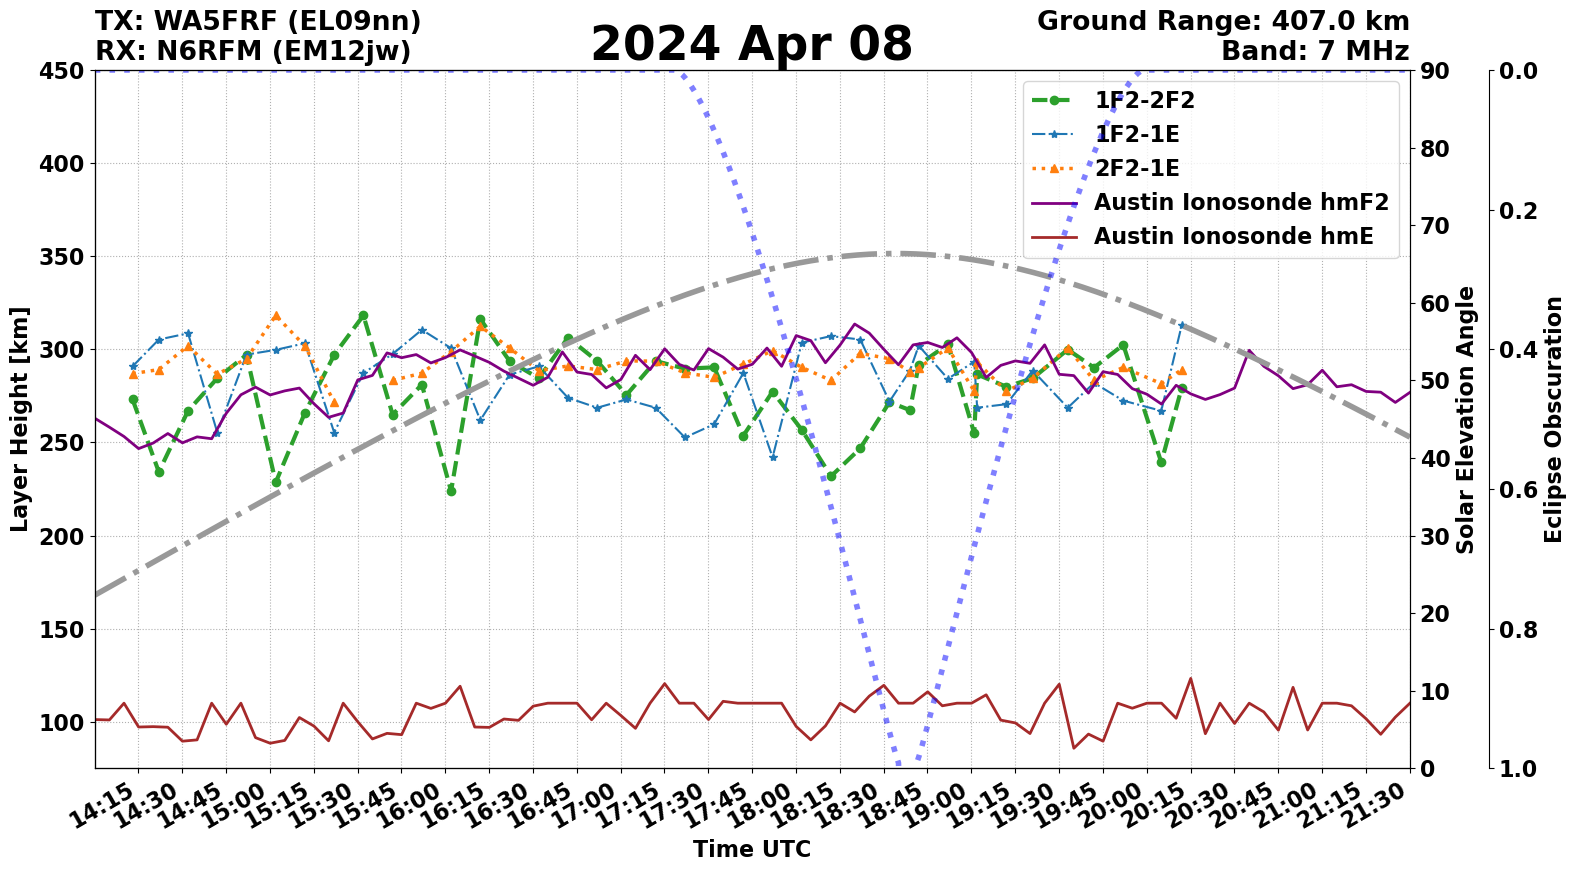

In [8]:
# Use the path midpoint for solar calculations
solar_lat, solar_lon = path_info.get_midpoint()

# Create enhanced plot with solar elevation and eclipse obscuration overlays
tdoa.plot_hmf2(chirps, tdoa_dct,
               solar_lat=solar_lat,
               solar_lon=solar_lon,
               overlay_solar_elevation=True,
               overlay_eclipse=True,
               ionosonde_dct=True)